# Decoder TransformerDecoder-only transformer implementations.

In [1]:
# Transformers example -> Sorting a sequence of numbers
%reload_ext autoreload
%autoreload 2

In [2]:
import flax.nnx as nnx
import jax
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt
import optax

from probjax.nn import PosEncode, Transformer

In [3]:
import jax
from jax import numpy as jnp

jnp.ones((10,))

Array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], dtype=float32)

In [34]:
T= 256

L = jax.random.gamma(jax.random.PRNGKey(0), 1.0, shape=(T, T))

cov = L @ L.T


def generate_data(key):
    x = jrandom.multivariate_normal(key, jnp.zeros(T), cov) * 0.5
    x = jax.nn.sigmoid(x)
    x = jax.random.bernoulli(key, x).astype(jnp.int32)
    return x

def generate_batch(key, batch_size):
    keys = jrandom.split(key, batch_size)
    return jax.vmap(generate_data)(keys).reshape(batch_size, T)


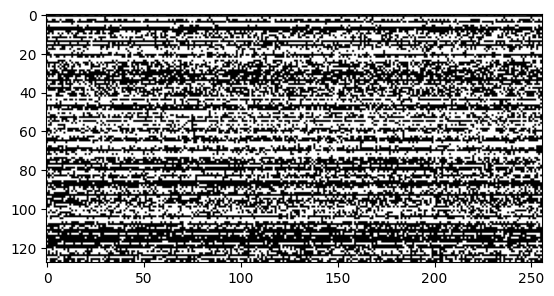

In [35]:
# Sequence of binary numbers
key = jrandom.PRNGKey(0)
y = generate_batch(key, 128)

plt.imshow(y, cmap='gray')

In [36]:
key = jrandom.PRNGKey(0)

In [40]:
class Model(nnx.Module):

    num_heads: int = 4
    num_layers: int = 6
    dim: int
    widening_factor: int = 2
    attn_size: int = 5

    def __init__(self, dim,rngs, dropout_rate=0.1):
        self.embed = nnx.Embed(2, dim, rngs=rngs)
        self.pos_embed = PosEncode(dim,rngs=rngs)
        self.transformer = Transformer(dim, self.num_heads,self.num_heads,self.attn_size, widening_factor=self.widening_factor,rngs=rngs, normalize_qk_attn=True,dropout_rate=dropout_rate)
        self.output = nnx.Linear(dim, 1, rngs=rngs)

    def __call__(self, x, decode=False, deterministic=False):
        x = self.embed(x)
        x = self.pos_embed(x)
        # Autoregressive mask
        start_token = jnp.zeros((x.shape[0], 1, x.shape[-1]))
        x = jnp.concatenate([start_token, x], axis=1)
        mask = jnp.tril(jnp.ones((x.shape[-2], x.shape[-2])))
        x = self.transformer(x, mask=mask, deterministic=deterministic, decode=decode)
        logits = self.output(x)
        return logits[:, :-1, :]


In [41]:
model = Model(50, rngs=nnx.Rngs(0), dropout_rate=None)

In [42]:
x = generate_batch(key,128)
model(x).shape

(128, 256, 1)

In [43]:
nnx.display(model)

In [44]:
params = nnx.state(model, nnx.Param)

In [45]:
scheduler = optax.cosine_onecycle_schedule(2000, 1e-2, final_div_factor=1)

optimizer = optax.adamw(scheduler)
opt_state = optimizer.init(params)

In [57]:

train_seq_len = [10]
def loss_fn(params,model, key):
    nnx.update(model, params)
    inp_data = generate_batch(key, 128)

    logit = model(inp_data)
    probs = jax.nn.sigmoid(logit).squeeze(-1)
    inp_data = inp_data.astype(jnp.float32)
    loss = -jnp.sum(inp_data * jnp.log(probs) + (1. - inp_data) * jnp.log(1 - probs),-1)
    return jnp.mean(loss)


@jax.jit
def update(params,model, key, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params,model, key)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [58]:
key = jrandom.PRNGKey(0)

In [59]:

for i in range(1_000):
    key, subkey, key2 = jrandom.split(key, 3)
    loss, params, opt_state = update(params,model,key, opt_state)
    if (i % 100) == 0:
        print(loss)

118.85864
121.451614
119.687706
121.92544
116.94693


KeyboardInterrupt: 

In [60]:
model.eval()
nnx.update(model, params)

In [61]:
inputs = generate_batch(key, 2)

In [62]:

def naive_autoregressive_decoding(key, T=T):
    x = jnp.zeros((1, T), dtype=jnp.bool_)
    def scan_fn(carry, k):
        x, i = carry
        logits = model(x.astype(jnp.int32))
        p_i = jax.nn.sigmoid(logits[0,i]).squeeze(-1)
        #jax.debug.print("p={p}", p=p_i)
        x_i = jax.random.bernoulli(k, p_i)
        x = x.at[0, i].set(x_i)
        return (x, i+1), None
    keys = jrandom.split(key, (T,))
    x, _ = jax.lax.scan(scan_fn, (x, 0), keys)

    return x[0].squeeze(0)

In [63]:
x = jnp.zeros((1, T), dtype=jnp.int32)

In [64]:
keys = jax.random.split(key, (512,))

In [65]:
samples = jax.vmap(naive_autoregressive_decoding)(keys)

Text(0.5, 1.0, 'Samples')

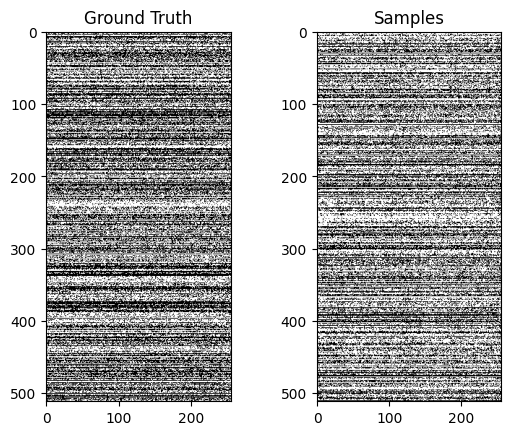

In [66]:
# Sequence of binary numbers
key = jrandom.PRNGKey(0)
y = generate_batch(key, 512)

# Plotting the samples next to the ground truth
fig, axs = plt.subplots(1, 2)
axs[0].imshow(y, cmap='gray')
axs[0].set_title('Ground Truth')
axs[1].imshow(samples, cmap='gray')
axs[1].set_title('Samples')

In [119]:
y.mean(0)

Array([0.531, 0.521, 0.521, 0.523, 0.523, 0.525, 0.527, 0.557, 0.512,
       0.496, 0.482, 0.514, 0.518, 0.527, 0.51 , 0.498, 0.502, 0.508,
       0.482, 0.504, 0.5  , 0.525, 0.516, 0.502, 0.518, 0.504, 0.539,
       0.506, 0.479, 0.531, 0.494, 0.484, 0.506, 0.541, 0.482, 0.494,
       0.502, 0.502, 0.5  , 0.496, 0.516, 0.498, 0.49 , 0.52 , 0.523,
       0.508, 0.514, 0.484, 0.506, 0.492], dtype=float32)

In [120]:
samples.mean(0)

Array([0.486, 0.535, 0.523, 0.492, 0.504, 0.51 , 0.471, 0.494, 0.494,
       0.52 , 0.502, 0.506, 0.496, 0.51 , 0.535, 0.48 , 0.512, 0.498,
       0.516, 0.496, 0.539, 0.502, 0.535, 0.498, 0.502, 0.5  , 0.502,
       0.518, 0.5  , 0.492, 0.506, 0.486, 0.494, 0.467, 0.488, 0.484,
       0.486, 0.492, 0.514, 0.475, 0.496, 0.494, 0.502, 0.49 , 0.486,
       0.484, 0.508, 0.498, 0.494, 0.502], dtype=float32)

In [129]:
jnp.cov(y.T).max()

Array(0.25, dtype=float32)

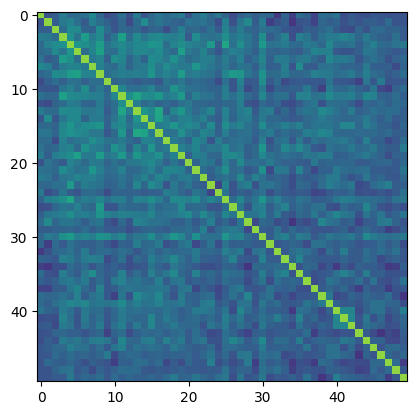

In [130]:
plt.imshow(jnp.cov(y.T), vmin=0, vmax=0.3)

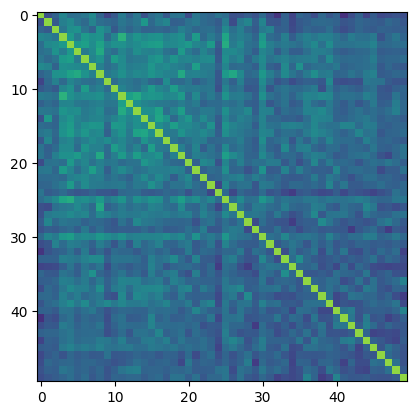

In [131]:
plt.imshow(jnp.cov(samples.T),vmin=0, vmax=0.3)